In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [6]:
# 1. Load the World Happiness dataset
data = pd.read_csv("2015.csv")

In [8]:
# 2. Select economic, health and social features
features = [
    "Economy (GDP per Capita)",
    "Family",
    "Health (Life Expectancy)",
    "Freedom"
]

X = data[features]

In [9]:
# 3. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# 4. Apply K-Means clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

data["Cluster"] = kmeans.fit_predict(X_scaled)


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [11]:
# 5. Display number of countries in each cluster
print("Number of countries in each cluster:")
print(data["Cluster"].value_counts().sort_index())

# 6. Calculate average Happiness Score for each cluster
cluster_happiness = data.groupby("Cluster")["Happiness Score"].mean()

print("\nAverage Happiness Score for each cluster:")
print(cluster_happiness)


Number of countries in each cluster:
Cluster
0    68
1    50
2    40
Name: count, dtype: int64

Average Happiness Score for each cluster:
Cluster
0    6.342456
1    4.246640
2    5.143675
Name: Happiness Score, dtype: float64


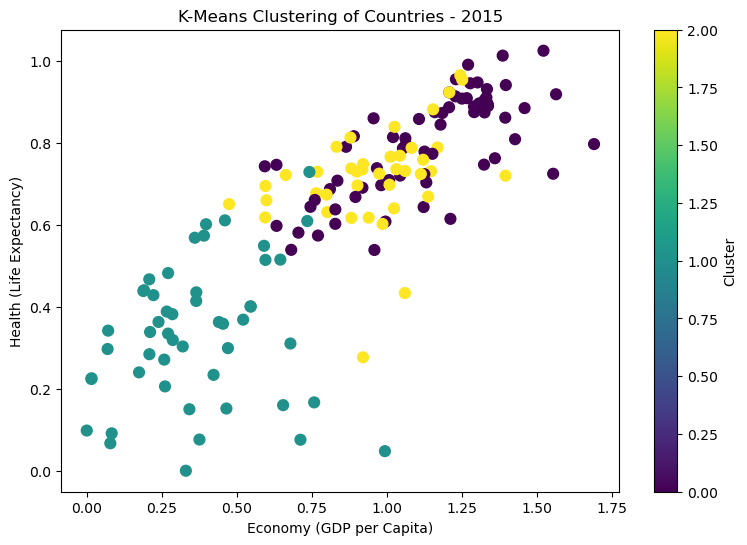

In [12]:
# 7. Visualize the clusters
plt.figure(figsize=(9, 6))

plt.scatter(
    data["Economy (GDP per Capita)"],
    data["Health (Life Expectancy)"],
    c=data["Cluster"],
    s=60
)

plt.xlabel("Economy (GDP per Capita)")
plt.ylabel("Health (Life Expectancy)")
plt.title("K-Means Clustering of Countries - 2015")
plt.colorbar(label="Cluster")

plt.show()

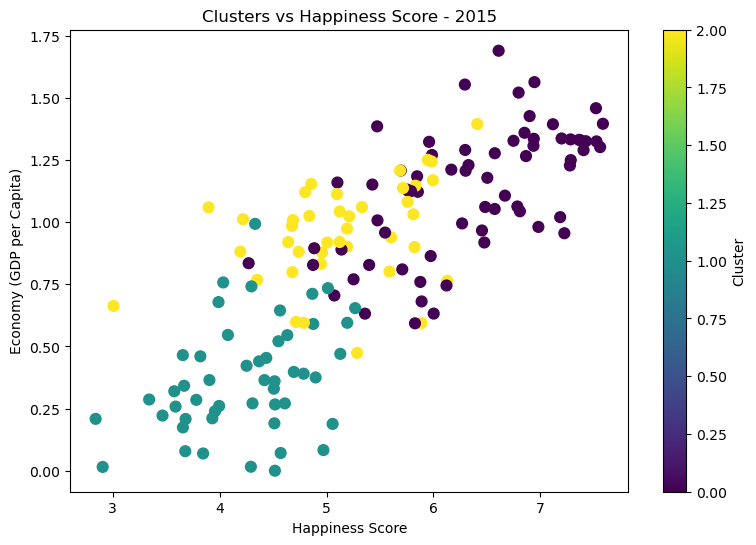

In [13]:
# 8. Visualize clusters against Happiness Score
plt.figure(figsize=(9, 6))

plt.scatter(
    data["Happiness Score"],
    data["Economy (GDP per Capita)"],
    c=data["Cluster"],
    s=60
)

plt.xlabel("Happiness Score")
plt.ylabel("Economy (GDP per Capita)")
plt.title("Clusters vs Happiness Score - 2015")
plt.colorbar(label="Cluster")

plt.show()